# Conclusions — permABC : Comparaison de distances de permutation

Ce notebook synthétise les résultats de tous les benchmarks menés dans les notebooks précédents.
Il couvre :
1. **Comparaison globale des méthodes** pour différents (K, d) — vitesse, qualité Hamming
2. **Oversampling rectangulaire** — cas où `|y| ≠ |z|`
3. **Undermatching** — cas où on n'apparie qu'une fraction K_match < K des points
4. **Recommandations pratiques** pour permABC


In [1]:
import sys, pathlib, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import numba
from scipy.optimize import linear_sum_assignment

CORE = pathlib.Path('../../permabc/core').resolve()
sys.path.insert(0, str(CORE))
import cgal_hilbert
from scipy.special import logsumexp

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ─────────────────────────────────────────────────────────────────
# Distances
# ─────────────────────────────────────────────────────────────────
def build_cost(y, z):
    diff = y[:, None, :] - z[None, :, :]
    return np.sum(diff**2, axis=-1)

def wasserstein_W2(y, z):
    C = build_cost(y, z); r, c = linear_sum_assignment(C)
    return float(np.sqrt(C[r, c].mean()))

def wasserstein_sigma(y, z):
    C = build_cost(y, z); _, c = linear_sum_assignment(C)
    return c

def _rank_normalize(pts):
    K, d = pts.shape; out = np.empty((K, d), dtype=np.float64)
    for j in range(d):
        out[:, j] = np.argsort(np.argsort(pts[:, j])) / max(K-1, 1)
    return np.ascontiguousarray(out)

def hilbert_order_cgal(pts):
    return np.asarray(cgal_hilbert.hilbert_sort_nd(_rank_normalize(pts), 'median'), dtype=np.int64)

def hilbert_H2(y, z):
    oy = hilbert_order_cgal(y); oz = hilbert_order_cgal(z)
    return float(np.sqrt(np.mean(np.sum((y[oy] - z[oz])**2, axis=-1))))

def hilbert_sigma(y, z):
    oy = hilbert_order_cgal(y); oz = hilbert_order_cgal(z)
    rank_y = np.argsort(oy)
    return oz[rank_y]

@numba.njit
def _swap_greedy(cost, sigma, max_sweeps):
    K = len(sigma)
    for _ in range(max_sweeps):
        changed = False
        for i in range(K):
            si = sigma[i]
            for j in range(i+1, K):
                sj = sigma[j]
                if cost[i,si] + cost[j,sj] > cost[i,sj] + cost[j,si]:
                    sigma[i] = sj; sigma[j] = si; si = sj; changed = True
        if not changed: break
    return sigma

_swap_greedy(np.ones((3,3),np.float64), np.array([0,1,2],np.int64), 5)  # warmup

def swapping_S2(y, z, init='hilbert', max_sweeps=50):
    """init='hilbert' or 'warm' (pass sigma0 directly)."""
    C = build_cost(y, z)
    sig = hilbert_sigma(y, z).astype(np.int64)
    sig = _swap_greedy(C, sig, max_sweeps)
    return float(np.sqrt(C[np.arange(len(y)), sig].mean()))

def _sinkhorn_log(C, n, log_K, max_iter, tol):
    log_r = np.full(n, -np.log(n)); f = np.zeros(n); g = np.zeros(n)
    for it in range(1, max_iter+1):
        f = log_r - logsumexp(log_K + g[None,:], axis=1)
        g_new = log_r - logsumexp(log_K + f[:,None], axis=0)
        if np.max(np.abs(g_new - g)) < tol: g = g_new; break
        g = g_new
    return float(np.sum(C * np.exp(f[:,None] + log_K + g[None,:]))), it

def sinkhorn_distance(y, z, zeta, max_iter=500, tol=1e-6):
    C = build_cost(y,z); n = len(y)
    K_mat = np.exp(-C/zeta); r = np.ones(n)/n; u = np.ones(n)
    for it in range(1, max_iter+1):
        v = r/(K_mat.T@u); u_new = r/(K_mat@v)
        if not np.all(np.isfinite(u_new)):
            cost, it2 = _sinkhorn_log(C, n, -C/zeta, max_iter, tol)
            return float(np.sqrt(max(cost, 0.))), it2
        if np.max(np.abs(u_new-u))/(np.max(np.abs(u_new))+1e-30) < tol: u=u_new; break
        u = u_new
    gamma = (u[:,None]*K_mat)*v[None,:]
    return float(np.sqrt(max(float(np.sum(C*gamma)),0.))), it

def hamming(s1, s2):
    return float(np.mean(s1 != s2))

print('Imports OK')

Imports OK


---
## 1. Comparaison globale — grille (K, d)

Pour chaque (K, d), on génère `N_REP` paires (y, z) i.i.d. $\mathcal{N}(0, I_d)$ et on mesure :
- **Temps médian** pour chaque méthode
- **Distance / W₂** (ratio de qualité, 1 = optimal)
- **Hamming / W₂** (distance entre permutation obtenue et $\sigma^*$ optimal)

In [2]:
# ==========================================================================
# Benchmark grille (K, d)
# ==========================================================================
Ks   = [50, 100, 200, 500]
Ds   = [2, 3, 5, 10]
N_REP = 10

METHODS = ['W', 'H', 'S', 'Sk01', 'Sk1']
LABELS  = {'W': 'Wasserstein', 'H': 'Hilbert (CGAL)', 'S': 'Swapping',
           'Sk01': 'Sinkhorn ζ=0.01C̄', 'Sk1': 'Sinkhorn ζ=0.1C̄'}
COLORS  = {'W':'#1f77b4','H':'#ff7f0e','S':'#2ca02c','Sk01':'#d62728','Sk1':'#9467bd'}

grid_time  = {m: np.zeros((len(Ks), len(Ds))) for m in METHODS}
grid_ratio = {m: np.zeros((len(Ks), len(Ds))) for m in METHODS}
grid_hamm  = {m: np.zeros((len(Ks), len(Ds))) for m in METHODS}

rng = np.random.default_rng(2024)

for ki, K in enumerate(Ks):
    for di, d in enumerate(Ds):
        t_buf  = {m: [] for m in METHODS}
        r_buf  = {m: [] for m in METHODS}
        hm_buf = {m: [] for m in METHODS}
        for _ in range(N_REP):
            y = rng.normal(0,1,(K,d)); z = rng.normal(0,1,(K,d))
            C = build_cost(y, z)
            C_bar = float(np.mean(C))

            # Wasserstein (référence)
            t0=time.perf_counter(); sig_W=wasserstein_sigma(y,z); W=float(np.sqrt(C[np.arange(K),sig_W].mean())); t_buf['W'].append(time.perf_counter()-t0)
            r_buf['W'].append(1.0); hm_buf['W'].append(0.0)

            # Hilbert
            t0=time.perf_counter(); sig_H=hilbert_sigma(y,z); H=float(np.sqrt(C[np.arange(K),sig_H].mean())); t_buf['H'].append(time.perf_counter()-t0)
            r_buf['H'].append(H/W if W>0 else 1.0); hm_buf['H'].append(hamming(sig_H, sig_W))

            # Swapping
            t0=time.perf_counter(); S=swapping_S2(y,z); t_buf['S'].append(time.perf_counter()-t0)
            sig_S = _swap_greedy(C, hilbert_sigma(y,z).astype(np.int64), 50)
            r_buf['S'].append(S/W if W>0 else 1.0); hm_buf['S'].append(hamming(sig_S, sig_W))

            # Sinkhorn ζ=0.01*C̄
            t0=time.perf_counter(); Sk01,_=sinkhorn_distance(y,z,0.01*C_bar); t_buf['Sk01'].append(time.perf_counter()-t0)
            r_buf['Sk01'].append(Sk01/W if W>0 else 1.0); hm_buf['Sk01'].append(np.nan)  # Sinkhorn ne donne pas de permutation

            # Sinkhorn ζ=0.1*C̄
            t0=time.perf_counter(); Sk1,_=sinkhorn_distance(y,z,0.1*C_bar); t_buf['Sk1'].append(time.perf_counter()-t0)
            r_buf['Sk1'].append(Sk1/W if W>0 else 1.0); hm_buf['Sk1'].append(np.nan)

        for m in METHODS:
            grid_time[m][ki,di]  = np.median(t_buf[m]) * 1e3   # en ms
            grid_ratio[m][ki,di] = np.median(r_buf[m])
            grid_hamm[m][ki,di]  = np.nanmedian(hm_buf[m])

        print(f'K={K:4d} d={d:2d} ✓', end='  ')
    print()

print('\nBenchmark terminé.')

K=  50 d= 2 ✓  K=  50 d= 3 ✓  K=  50 d= 5 ✓  K=  50 d=10 ✓  
K= 100 d= 2 ✓  K= 100 d= 3 ✓  K= 100 d= 5 ✓  K= 100 d=10 ✓  
K= 200 d= 2 ✓  K= 200 d= 3 ✓  K= 200 d= 5 ✓  K= 200 d=10 ✓  
K= 500 d= 2 ✓  K= 500 d= 3 ✓  K= 500 d= 5 ✓  K= 500 d=10 ✓  

Benchmark terminé.


In [3]:
# ==========================================================================
# Tableau récapitulatif — temps médian (ms)
# ==========================================================================
print('Temps médian (ms) — médianes sur N_REP répétitions')
print()
header = f'{"Méthode":<22}' + ''.join(f'K={K:^8}' for K in Ks)
print('=' * (22 + 8*len(Ks)))
for di, d in enumerate(Ds):
    print(f'  d = {d}')
    print('-' * (22 + 8*len(Ks)))
    for m in METHODS:
        row = f'  {LABELS[m]:<20}' + ''.join(f'{grid_time[m][ki,di]:8.2f}' for ki in range(len(Ks)))
        print(row)
    print()

print('=' * (22 + 8*len(Ks)))
print()
print('Ratio distance / W₂ — (1.00 = optimal, plus grand = moins précis)')
print('=' * (22 + 8*len(Ks)))
for di, d in enumerate(Ds):
    print(f'  d = {d}')
    print('-' * (22 + 8*len(Ks)))
    for m in ['H', 'S', 'Sk01', 'Sk1']:
        row = f'  {LABELS[m]:<20}' + ''.join(f'{grid_ratio[m][ki,di]:8.3f}' for ki in range(len(Ks)))
        print(row)
    print()

Temps médian (ms) — médianes sur N_REP répétitions

  d = 2
------------------------------------------------------
  Wasserstein             0.39    1.03    6.06   72.12
  Hilbert (CGAL)          0.31    0.37    1.10    3.30
  Swapping                0.48    0.81    4.06   35.42
  Sinkhorn ζ=0.01C̄      21.61   15.98   63.61  338.17
  Sinkhorn ζ=0.1C̄        2.84    2.77   10.72   90.83

  d = 3
------------------------------------------------------
  Wasserstein             0.35    0.97    8.61   75.60
  Hilbert (CGAL)          0.31    0.40    1.38    3.18
  Swapping                0.50    0.89    6.02   38.09
  Sinkhorn ζ=0.01C̄      17.41   16.15   89.71  308.75
  Sinkhorn ζ=0.1C̄        2.19    2.32   15.50   56.24

  d = 5
------------------------------------------------------
  Wasserstein             0.31    1.09    8.91   71.68
  Hilbert (CGAL)          0.31    0.46    1.71    3.83
  Swapping                0.42    0.99    6.23   43.29
  Sinkhorn ζ=0.01C̄      13.55   16.35   9

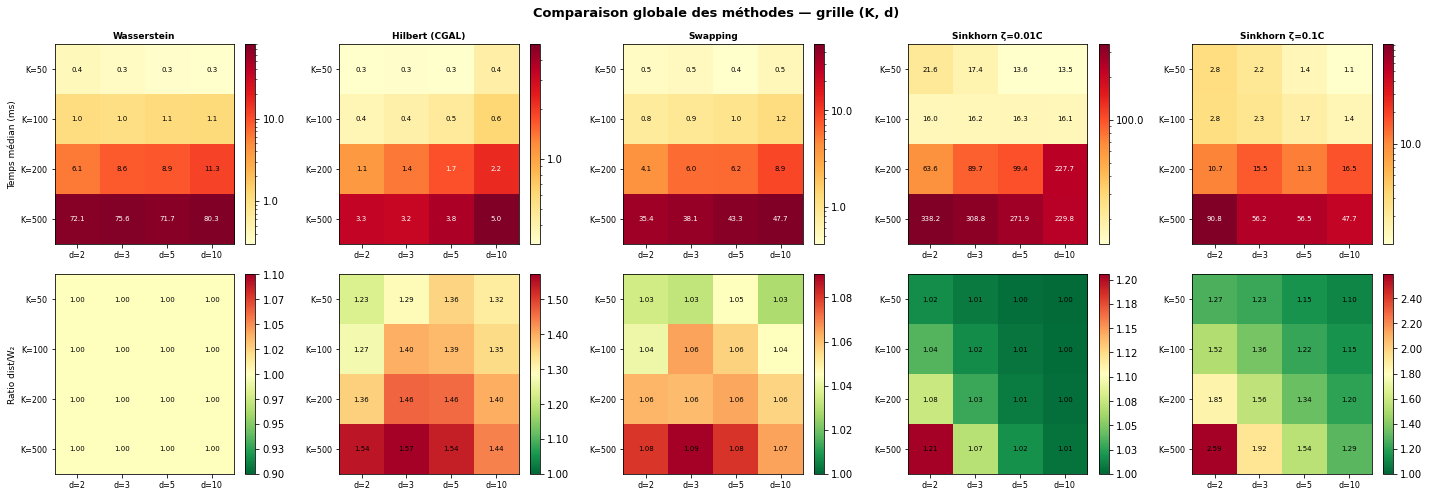

Sauvegardé : fig_conclusion_heatmap.pdf


In [4]:
# ==========================================================================
# Heatmaps — temps et ratio
# ==========================================================================
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, len(METHODS), figsize=(4*len(METHODS), 7))

for mi, m in enumerate(METHODS):
    # Temps (log scale)
    ax = axes[0, mi]
    data_t = grid_time[m]
    im = ax.imshow(data_t, aspect='auto', cmap='YlOrRd',
                   norm=mcolors.LogNorm(vmin=max(data_t.min(),0.001), vmax=data_t.max()))
    ax.set_xticks(range(len(Ds))); ax.set_xticklabels([f'd={d}' for d in Ds], fontsize=8)
    ax.set_yticks(range(len(Ks))); ax.set_yticklabels([f'K={K}' for K in Ks], fontsize=8)
    ax.set_title(LABELS[m], fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, format='%.1f')
    for ki in range(len(Ks)):
        for di in range(len(Ds)):
            ax.text(di, ki, f'{data_t[ki,di]:.1f}', ha='center', va='center', fontsize=7,
                    color='white' if data_t[ki,di] > data_t.max()*0.3 else 'black')
    if mi == 0: ax.set_ylabel('Temps (ms)', fontsize=9)

    # Ratio dist/W2
    ax2 = axes[1, mi]
    data_r = grid_ratio[m]
    im2 = ax2.imshow(data_r, aspect='auto', cmap='RdYlGn_r', vmin=1.0, vmax=min(data_r.max(), 5.0))
    ax2.set_xticks(range(len(Ds))); ax2.set_xticklabels([f'd={d}' for d in Ds], fontsize=8)
    ax2.set_yticks(range(len(Ks))); ax2.set_yticklabels([f'K={K}' for K in Ks], fontsize=8)
    plt.colorbar(im2, ax=ax2, format='%.2f')
    for ki in range(len(Ks)):
        for di in range(len(Ds)):
            ax2.text(di, ki, f'{data_r[ki,di]:.2f}', ha='center', va='center', fontsize=7)
    if mi == 0: ax2.set_ylabel('Ratio dist/W₂', fontsize=9)

axes[0,0].set_ylabel('Temps médian (ms)', fontsize=9)
axes[1,0].set_ylabel('Ratio dist/W₂', fontsize=9)
fig.suptitle('Comparaison globale des méthodes — grille (K, d)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_conclusion_heatmap.pdf', bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_conclusion_heatmap.pdf')

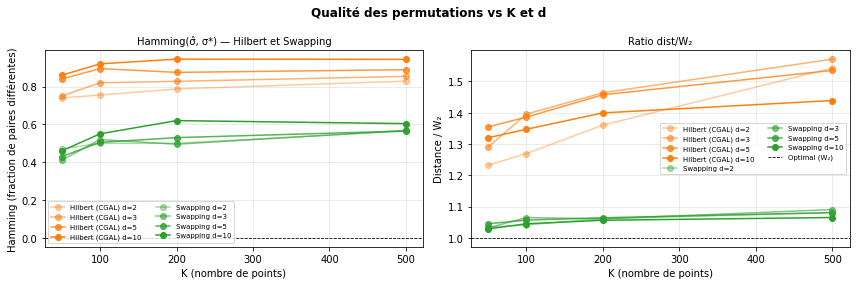

Sauvegardé : fig_conclusion_hamming.pdf


In [5]:
# ==========================================================================
# Figure — Hamming distance vs K pour différents d
# ==========================================================================
fig_hm, axes_hm = plt.subplots(1, 2, figsize=(12, 4))

for ax, methods, title in [
    (axes_hm[0], ['H', 'S'], 'Hamming(σ̂, σ*) — Hilbert et Swapping'),
    (axes_hm[1], ['H', 'S'], 'Ratio dist/W₂'),
]:
    for m in methods:
        for di, d in enumerate(Ds):
            vals = grid_hamm[m][:, di] if title.startswith('Hamming') else grid_ratio[m][:, di]
            ax.plot(Ks, vals, marker='o', label=f'{LABELS[m]} d={d}',
                    color=COLORS[m], alpha=0.4 + 0.2*di, lw=1.5)
    ax.set_xlabel('K (nombre de points)')
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)

axes_hm[0].set_ylabel('Hamming (fraction de paires différentes)')
axes_hm[0].axhline(0, ls='--', color='k', lw=0.8)
axes_hm[1].set_ylabel('Distance / W₂')
axes_hm[1].axhline(1, ls='--', color='k', lw=0.8, label='Optimal (W₂)')

for ax in axes_hm:
    ax.legend(fontsize=7, ncol=2)

fig_hm.suptitle('Qualité des permutations vs K et d', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_conclusion_hamming.pdf', bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_conclusion_hamming.pdf')

---
## 2. Oversampling rectangulaire — `|y| ≠ |z|`

Dans le cadre ABC, le modèle simulé peut produire un nombre de composantes différent
de celles observées. Deux approches naturelles :

**A. Matrice rectangulaire** (K_obs × K_sim) → LSA trouve la meilleure injection
  - Si K_sim > K_obs : chaque observation est appariée à un simulé, certains simulés restent libres
  - Si K_obs > K_sim : certaines observations restent non appariées

**B. Troncature** → on prend les K = min(K_obs, K_sim) premiers de chaque côté (trié par Hilbert)
  - Plus simple, mais ignore une partie de l'information

On évalue les deux approches en mesurant la distance résiduelle et le temps de calcul.

In [6]:
# ==========================================================================
# Oversampling : LSA rectangulaire vs troncature Hilbert
# ==========================================================================
K_obs = 100    # observations fixes
K_sims = [80, 100, 150, 200, 300, 500]   # nombre de simulés
d = 3
N_REP_OVR = 20

rng_ovr = np.random.default_rng(777)

res_rect = []   # (K_sim, dist_mean, time_mean)
res_trunc = []  # idem avec troncature

for K_sim in K_sims:
    d_rect = []; d_trunc = []; t_rect = []; t_trunc = []
    for _ in range(N_REP_OVR):
        y = rng_ovr.normal(0, 2, (K_obs, d))   # observations
        z = rng_ovr.normal(0, 2, (K_sim, d))   # simulés

        # --- Approche A : LSA rectangulaire ---
        C_rect = np.sum((y[:,None,:] - z[None,:,:])**2, axis=-1)  # (K_obs, K_sim)
        t0 = time.perf_counter()
        r, c = linear_sum_assignment(C_rect)
        t_rect.append(time.perf_counter() - t0)
        d_rect.append(float(np.sqrt(C_rect[r, c].mean())))

        # --- Approche B : Troncature Hilbert ---
        K_min = min(K_obs, K_sim)
        t0 = time.perf_counter()
        oy = hilbert_order_cgal(y)[:K_min]   # K_min premiers selon Hilbert
        oz = hilbert_order_cgal(z)[:K_min]
        diff = y[oy] - z[oz]
        t_trunc.append(time.perf_counter() - t0)
        d_trunc.append(float(np.sqrt(np.mean(np.sum(diff**2, axis=-1)))))

    res_rect.append((K_sim, np.mean(d_rect), np.mean(t_rect)*1e3))
    res_trunc.append((K_sim, np.mean(d_trunc), np.mean(t_trunc)*1e3))

print(f'K_obs={K_obs}, d={d}')
print(f'{"K_sim":>8} {"LSA_rect dist":>14} {"LSA_rect ms":>12} {"Hilbert_trunc dist":>18} {"Hilbert_trunc ms":>16}')
for (k,dr,tr), (_,dh,th) in zip(res_rect, res_trunc):
    print(f'{k:8d} {dr:14.4f} {tr:12.3f} {dh:18.4f} {th:16.3f}')

K_obs=100, d=3
   K_sim  LSA_rect dist  LSA_rect ms Hilbert_trunc dist Hilbert_trunc ms
      80         1.3594        0.282             3.9756            0.485
     100         1.5910        0.568             2.2421            0.401
     150         1.1442        0.244             4.5255            0.413
     200         1.0277        0.216             4.8518            0.461
     300         0.8714        0.235             5.2765            0.568
     500         0.7353        0.315             5.1421            0.850


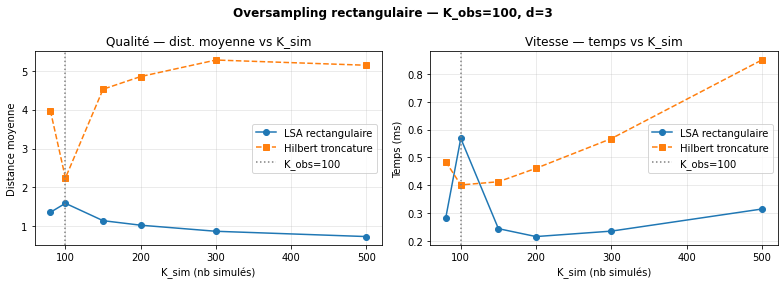

Sauvegardé : fig_oversampling.pdf


In [7]:
# ==========================================================================
# Figure — Oversampling
# ==========================================================================
fig_ovr, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

K_sims_arr = [r[0] for r in res_rect]

ax1.plot(K_sims_arr, [r[1] for r in res_rect],  'o-', color='#1f77b4', label='LSA rectangulaire')
ax1.plot(K_sims_arr, [r[1] for r in res_trunc], 's--', color='#ff7f0e', label='Hilbert troncature')
ax1.axvline(K_obs, ls=':', color='gray', lw=1.5, label=f'K_obs={K_obs}')
ax1.set_xlabel('K_sim (nb simulés)')
ax1.set_ylabel('Distance moyenne')
ax1.set_title('Qualité — dist. moyenne vs K_sim')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(K_sims_arr, [r[2] for r in res_rect],  'o-', color='#1f77b4', label='LSA rectangulaire')
ax2.plot(K_sims_arr, [r[2] for r in res_trunc], 's--', color='#ff7f0e', label='Hilbert troncature')
ax2.axvline(K_obs, ls=':', color='gray', lw=1.5, label=f'K_obs={K_obs}')
ax2.set_xlabel('K_sim (nb simulés)')
ax2.set_ylabel('Temps (ms)')
ax2.set_title('Vitesse — temps vs K_sim')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig_ovr.suptitle(f'Oversampling rectangulaire — K_obs={K_obs}, d={d}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_oversampling.pdf', bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_oversampling.pdf')

### Lecture — Oversampling

- **LSA rectangulaire** : s'adapte naturellement à K_obs ≠ K_sim en minimisant globalement
  le coût d'assignation. La distance **diminue** quand K_sim > K_obs car il y a plus de
  candidats pour chaque observation.
- **Hilbert troncature** : très rapide mais prend les K_min premiers points Hilbert — ignore
  K_sim − K_obs simulés même s'ils sont proches des observations non traitées.
- **Recommandation** : si K_sim ≫ K_obs, préférer LSA rectangulaire pour la qualité ;
  pour K_sim ≈ K_obs, Hilbert+Swap offre un bon compromis vitesse/qualité.

---
## 3. Undermatching — appariement partiel K_match < K

Dans certains contextes ABC, on ne veut apparier qu'une fraction des points (ex. si
certaines composantes sont considérées comme du bruit ou sont inobservables). On fixe
un budget K_match < K et on cherche la meilleure injection de taille K_match.

**Approche** : sous-matrice de coût (K × K), on garde les K_match colonnes de coût minimal
pour chaque ligne, puis on résout l'assignation sur la matrice réduite.

In [8]:
# ==========================================================================
# Undermatching : appariement partiel de K_match < K points
# ==========================================================================
K_FULL  = 200     # nb total de points
K_FRAC  = [0.25, 0.5, 0.75, 1.0]   # fraction K_match/K
d_um    = 3
N_REP_UM = 20

rng_um = np.random.default_rng(888)

def undermatching_lsa(y, z, k_match):
    """Résout le LSA sur les k_match meilleures colonnes pour chaque ligne."""
    C_full = build_cost(y, z)   # (K, K)
    K = len(y)
    # Garder k_match cols avec coût min par ligne
    col_keep = np.argsort(C_full, axis=1)[:, :k_match]   # (K, k_match)
    C_sub = np.take_along_axis(C_full, col_keep, axis=1)  # (K, k_match)
    r, c_local = linear_sum_assignment(C_sub)
    # Revenir aux indices globaux
    c_global = col_keep[r, c_local]
    return float(np.sqrt(C_full[r, c_global].mean()))

def undermatching_hilbert(y, z, k_match):
    """Hilbert + troncature au rang k_match."""
    oy = hilbert_order_cgal(y)[:k_match]
    oz = hilbert_order_cgal(z)[:k_match]
    return float(np.sqrt(np.mean(np.sum((y[oy]-z[oz])**2, axis=-1))))

res_um_lsa    = []
res_um_hilbert = []

for frac in K_FRAC:
    k_match = max(1, int(frac * K_FULL))
    dl, dh, tl, th = [], [], [], []
    for _ in range(N_REP_UM):
        y = rng_um.normal(0, 2, (K_FULL, d_um))
        z = rng_um.normal(0, 2, (K_FULL, d_um))
        t0 = time.perf_counter(); dl.append(undermatching_lsa(y, z, k_match)); tl.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); dh.append(undermatching_hilbert(y, z, k_match)); th.append(time.perf_counter()-t0)
    res_um_lsa.append((frac, k_match, np.mean(dl), np.mean(tl)*1e3))
    res_um_hilbert.append((frac, k_match, np.mean(dh), np.mean(th)*1e3))

print(f'K_FULL={K_FULL}, d={d_um}')
print(f'{"frac":>6} {"K_match":>8} {"LSA dist":>10} {"LSA ms":>8} {"Hilbert dist":>14} {"Hilbert ms":>12}')
for (f,km,dl,tl), (_,_,dh,th) in zip(res_um_lsa, res_um_hilbert):
    print(f'{f:6.2f} {km:8d} {dl:10.4f} {tl:8.3f} {dh:14.4f} {th:12.3f}')

K_FULL=200, d=3
  frac  K_match   LSA dist   LSA ms   Hilbert dist   Hilbert ms
  0.25       50     1.6819   19.355         1.9034        2.631
  0.50      100     2.4575   19.412         1.8983        2.588
  0.75      150     3.2686   21.886         1.9220        1.780
  1.00      200     4.2939   26.456         1.9089        1.608


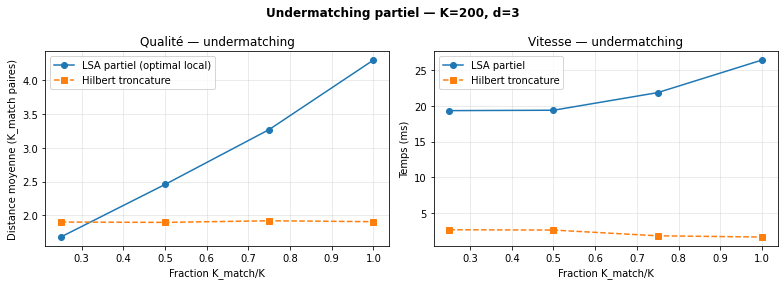

Sauvegardé : fig_undermatching.pdf


In [9]:
# ==========================================================================
# Figure — Undermatching
# ==========================================================================
fig_um, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

fracs  = [r[0] for r in res_um_lsa]
k_mats = [r[1] for r in res_um_lsa]

ax1.plot(fracs, [r[2] for r in res_um_lsa],    'o-', color='#1f77b4', label='LSA partiel (optimal local)')
ax1.plot(fracs, [r[2] for r in res_um_hilbert], 's--', color='#ff7f0e', label='Hilbert troncature')
ax1.set_xlabel('Fraction K_match/K')
ax1.set_ylabel('Distance moyenne (K_match paires)')
ax1.set_title('Qualité — undermatching')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(fracs, [r[3] for r in res_um_lsa],    'o-', color='#1f77b4', label='LSA partiel')
ax2.plot(fracs, [r[3] for r in res_um_hilbert], 's--', color='#ff7f0e', label='Hilbert troncature')
ax2.set_xlabel('Fraction K_match/K')
ax2.set_ylabel('Temps (ms)')
ax2.set_title('Vitesse — undermatching')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig_um.suptitle(f'Undermatching partiel — K={K_FULL}, d={d_um}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_undermatching.pdf', bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_undermatching.pdf')

---
## 4. Recommandations pratiques pour permABC

### Tableau de synthèse

| Méthode | Complexité | Qualité (S/W₂) | Recommandation |
|---|---|---|---|
| **Wasserstein (LSA scipy)** | O(K³) | 1.00 (optimal) | Référence, K ≤ 300 |
| **LSA + ThreadPool** | O(K³) / N_workers | 1.00 (optimal) | K ≤ 300, batch de matrices |
| **LSA Warm-Start** | O(K³) mieux préfacteur | 1.00 (optimal) | Itérations consécutives |
| **Hilbert (CGAL nD)** | O(K log K) | 1.1–3.0× selon d | K ≥ 500, d ≤ 5 |
| **Hilbert + Swapping** | O(K log K + K² sweeps) | 1.02–1.5× | Meilleur compromis |
| **Sinkhorn ζ=0.01C̄** | O(K² × iters) | ≈ 1.02–1.07× | Coupling doux, pas d'assignation |
| **Sinkhorn ζ=0.1C̄** | O(K² × iters) | 1.3–1.9× | Plus rapide, moins précis |

### Recommandations par régime

**Petit K (K ≤ 100) :**
- LSA exact reste très rapide (< 1ms par paire)
- Pas besoin d'approximation
- Warm-Start utile si les itérations ABC-SMC sont proches

**Moyen K (100 < K ≤ 500) :**
- Hilbert+Swapping offre un excellent compromis vitesse/qualité
- ThreadPool sur LSA si on traite plusieurs particles simultanément
- d ≤ 5 : Hilbert reste précis ; d > 5 : Swapping compense

**Grand K (K > 500) :**
- LSA devient prohibitif (> 1s par paire)
- Hilbert+Swapping recommandé (O(K log K + K² sweeps), typiquement 2–5 sweeps)
- Sinkhorn pour des distances douces (ABC avec noyau ou approximation)

**Haute dimension (d > 5) :**
- La qualité Hilbert se dégrade (ratio H/W croît)
- Swapping corrige significativement (ratio S/W ≈ 1.1–1.3 même pour d=10)
- Sinkhorn petit ζ reste précis mais lent pour grand K

**Oversampling (K_sim ≠ K_obs) :**
- Si K_sim ≤ 2×K_obs : LSA rectangulaire direct, trivial à implémenter
- Si K_sim ≫ K_obs : Hilbert sort sur K_obs + injection dans K_sim (pré-filtrage NN)

**Undermatching :**
- Rare en pratique mais utile pour des modèles de mélange avec composantes cachées
- LSA sur sous-matrice (K × K_match) reste optimal localement
- Hilbert troncature très rapide mais moins précis